In [1]:
import cfe

cfe.logger.setLevel("DEBUG")
cfe.settings.backend = "dynverse_docker"

[10/30/2025 12:45:53] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

In [2]:
fadata = cfe.data.read_h5ad("../../tests/data/pancrease_scvelo_500_fadata.h5ad")
fadata.add_prior_information(start_cell="cell_000")
fadata.layers["counts"] = fadata.X
fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    unserialize trajectory dict: 'ref'                                                                                                                                       
                      DEBUG    parse 'MilestoneWrapper' object for ref                                                                                                                              

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    uns: 'cfe', 'id'
    obsm: 'X_pca', 'X_umap'
    layers: 'count', 'expression', 'spliced', 'unspliced', 'counts'

In [ ]:
import scvelo as scv

scv.pp.filter_and_normalize(fadata, n_top_genes=2000)
fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             


                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                    

IORegistryError: No method registered for writing <class 'cfe.data.fate_milestone_wrapper.MilestoneWrapper'> into <class 'h5py._hl.group.Group'>

In [4]:
# TODO: fix for filter cells by inner preprocessing
method2parameters = {
    "ti_slingshot": {},
    # "ti_celltree_maptpx": {},
    # "ti_paga": {},
    # "ti_tscan": {}, # TODO:
    # "ti_raceid_stemid": {}, # TODO:
    # "ti_monocle_ica": {}, # TODO:
    
}

for method_name, parameters in method2parameters.items():
    parameters["repreprocess"] = False # use common preprocessing
    parameters["benchmark_resource"] = True # record resource usage
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)

                      DEBUG    Docker image(dynverse/ti_slingshot:v1.0.3) loaded, entry point is '['/code/run.R']'                                                                                      
[10/29/2025 05:03:16] INFO     method backend loaded: Dynverse Docker Backend: docker image 'dynverse/ti_slingshot:v1.0.3'                                                                              
                      DEBUG    extract .obs['clusters'](500) in as prior information `groups_id` key for dynverse                                                                                       
                      WARNING                                                                                                                                                                           
                                               Prior information end_id is optional, but missing from dataset 20251029_170314__FateAnnData__eRm1r326bm.                                             

In [5]:
# model_name_list = fadata.get_all_model_name(parse=False)
# color_list = ["clusters", "milestone"]

# cfe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

In [6]:
fadata.get_trajectory_dict("ti_tscan-dynverse_docker")

                      DEBUG    'ref' is not a valid random_time_string, don't need parse                                                                                                                
                      DEBUG    model 'ti_tscan-dynverse_docker' not found in trajectory_history_dict                                                                                                    


                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:20251029_170316__ti_slingshot-dynverse_docker__x7cDRXIBGW, basis:X_umap.                                               
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
[10/29/2025 05:03:31] DEBUG    add waypoints shape is (208, 500) for '20251029_170316__ti_slingshot-dynverse_docker__x7cDRXIBGW', finished!                                                         

<Axes: title={'center': 'ti_slingshot-dynverse_docker(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

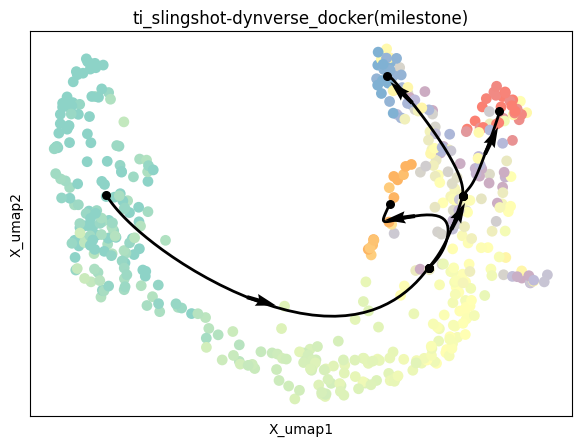

In [7]:
cfe.plot.plot_trajectory(fadata, color="milestone")